In [1114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [1115]:
path = "data/data.csv"

In [1116]:
df = pd.read_csv(path)

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [1117]:
df.shape

(4600, 18)

### Ý nghĩa các cột trong bộ dữ liệu Giá nhà (House Sales Data)

| Tên cột | Ý nghĩa | Mô tả chi tiết |
| :--- | :--- | :--- |
| **date** | Ngày bán | Thời gian căn nhà được giao dịch (YYYY-MM-DD). |
| **price** | Giá bán | Giá của căn nhà (Biến mục tiêu cần dự đoán). |
| **bedrooms** | Phòng ngủ | Số lượng phòng ngủ trong nhà. |
| **bathrooms** | Phòng tắm | Số lượng phòng tắm (ví dụ: 1.5 nghĩa là 1 phòng đầy đủ và 1 phòng vệ sinh). |
| **sqft_living** | Diện tích ở | Diện tích không gian sống bên trong căn nhà (tính bằng feet vuông). |
| **sqft_lot** | Diện tích đất | Diện tích toàn bộ lô đất bao gồm cả sân vườn. |
| **floors** | Số tầng | Số tầng của căn nhà. |
| **waterfront** | View mặt nước | 0: Không có view biển/hồ; 1: Có view mặt nước. |
| **view** | Chỉ số tầm nhìn | Đánh giá mức độ đẹp của view (từ 0 đến 4). |
| **condition** | Tình trạng | Đánh giá chất lượng hạ tầng nhà (từ 1 đến 5). |
| **sqft_above** | Diện tích nổi | Diện tích không gian sống trên mặt đất (không tính hầm). |
| **sqft_basement** | Diện tích hầm | Diện tích phần không gian sống nằm dưới tầng hầm. |
| **yr_built** | Năm xây dựng | Năm ngôi nhà được hoàn thành xây dựng lần đầu. |
| **yr_renovated** | Năm cải tạo | Năm gần nhất nhà được sửa chữa (nếu bằng 0 là chưa từng cải tạo). |
| **street** | Tên đường | Địa chỉ cụ thể của căn nhà. |
| **city** | Thành phố | Thành phố nơi căn nhà tọa lạc. |
| **statezip** | Mã bưu chính | Bao gồm tên bang (WA) và mã vùng (Zip code). |
| **country** | Quốc gia | Quốc gia của bộ dữ liệu (thường là USA). |

### Data Clearning

In [1118]:
df.drop(["date", "street", "country"], inplace=True, axis=1)
df = df.drop_duplicates()
df = df[df['price'] > 100000]
df = df.dropna()
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [1119]:
df.shape

(4538, 15)

In [1120]:
# xử lý các giá trị outlier

def get_lower_bound(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    return Q1 - 1.5 * (Q3 - Q1)

def get_upper_bound(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    return Q1 + 1.5 * (x.quantile(0.75) - x.quantile(0.25))

df['lower_limit'] = df.groupby('city')['price'].transform(get_lower_bound)
df['upper_limit'] = df.groupby('city')['price'].transform(get_upper_bound)

df_clean = df[(df['price'] >= df['lower_limit']) & (df['price'] <= df['upper_limit'])].copy()

df_clean.drop(columns=['lower_limit', 'upper_limit'], inplace=True)

print(f"Số lượng dòng trước khi lọc: {len(df)}")
print(f"Số lượng dòng sau khi lọc: {len(df_clean)}")

df = df_clean

Số lượng dòng trước khi lọc: 4538
Số lượng dòng sau khi lọc: 3907


In [1121]:
# Capping outliers cho diện tích
cols_area = ['sqft_living', 'sqft_lot', 'sqft_above']

for col in cols_area:
    upper_limit = df[col].quantile(0.95) # Chặn ở mức 95%
    df[col] = df[col].clip(upper=upper_limit)

print("Đã chặn trên (Capping) cho 3 cột diện tích ở ngưỡng 95th percentile.")

Đã chặn trên (Capping) cho 3 cột diện tích ở ngưỡng 95th percentile.


### EDA

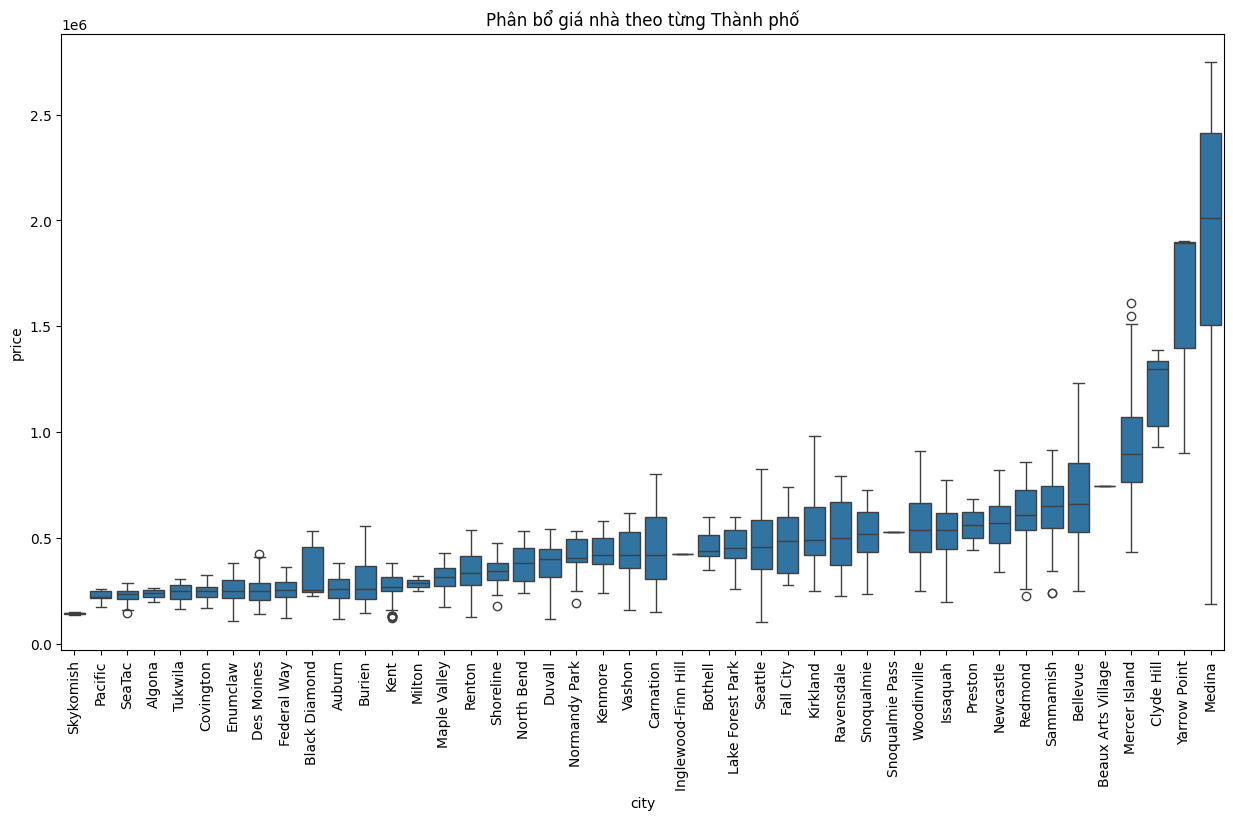

In [1122]:
# quan sát biến phân loại thành phố với price để tìm cách xử lý cho biến city 

city_order = df.groupby('city')['price'].median().sort_values(ascending=True).index

plt.figure(figsize=(15, 8))
sns.boxplot(x='city', y='price', data=df, order=city_order)
plt.xticks(rotation=90)
plt.title('Phân bổ giá nhà theo từng Thành phố')
plt.show()

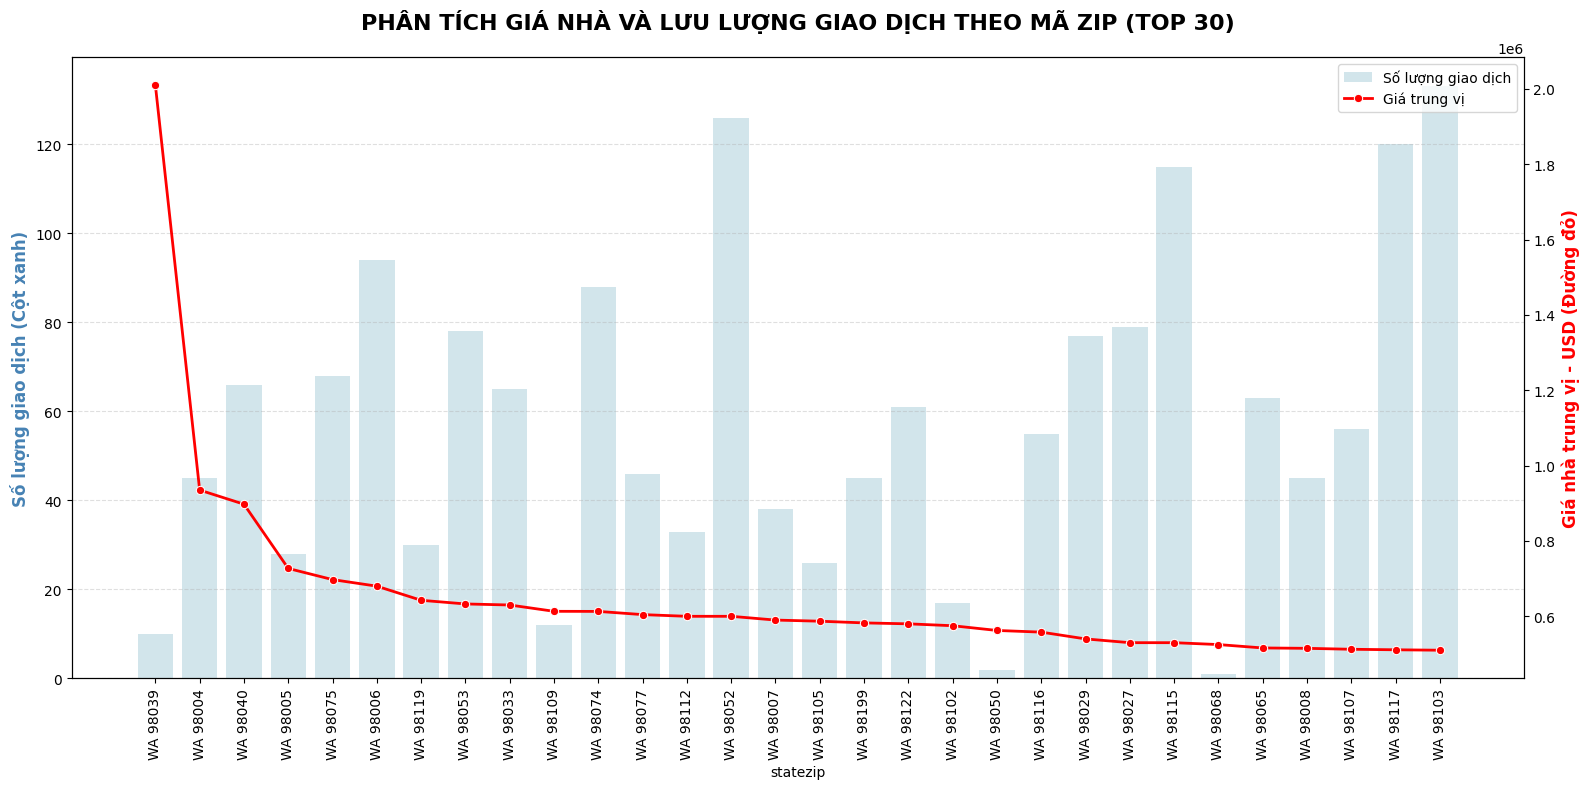

In [1123]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu
zip_stats = df.groupby('statezip').agg({'price': ['median', 'count']})
zip_stats.columns = ['median_price', 'count']
zip_stats = zip_stats.sort_values(by='median_price', ascending=False)
top_30_stats = zip_stats.head(30)

# 2. Khởi tạo biểu đồ
fig, ax1 = plt.subplots(figsize=(16, 8))

# Vẽ cột số lượng giao dịch (Bar Chart) - Vẫn giữ label để gộp vào legend cuối cùng
sns.barplot(x=top_30_stats.index, y=top_30_stats['count'], ax=ax1, color='lightblue', alpha=0.6, label='Số lượng giao dịch')
ax1.set_ylabel('Số lượng giao dịch (Cột xanh)', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='x', rotation=90)

# Vẽ đường giá trung vị (Line Chart)
ax2 = ax1.twinx()
sns.lineplot(x=top_30_stats.index, y=top_30_stats['median_price'], ax=ax2, color='red', marker='o', linewidth=2, label='Giá trung vị')
ax2.set_ylabel('Giá nhà trung vị - USD (Đường đỏ)', fontsize=12, fontweight='bold', color='red')

# 3. Hoàn thiện format
plt.title('PHÂN TÍCH GIÁ NHÀ VÀ LƯU LƯỢNG GIAO DỊCH THEO MÃ ZIP (TOP 30)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Lấy handles và labels từ cả 2 trục để gộp lại
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Chỉ vẽ 1 bảng chú thích duy nhất ở góc trên bên phải
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

if ax1.get_legend(): ax1.get_legend().remove()

plt.tight_layout()
plt.show()

In [1124]:
df.describe().round(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00,3907.00
mean,468535.25,3.31,2.04,1910.29,9681.05,1.47,0.00,0.13,3.45,1644.39,268.55,1970.34,824.53
std,218296.56,0.87,0.69,670.84,8407.09,0.54,0.04,0.55,0.67,638.46,406.10,29.08,982.48
min,102500.00,1.00,0.75,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,310000.00,3.00,1.50,1400.00,5000.00,1.00,0.00,0.00,3.00,1150.00,0.00,1951.00,0.00
50%,435000.00,3.00,2.00,1840.00,7500.00,1.00,0.00,0.00,3.00,1480.00,0.00,1974.00,0.00
75%,585000.00,4.00,2.50,2370.00,10258.50,2.00,0.00,0.00,4.00,2040.00,530.00,1995.00,2000.00
max,2750000.00,9.00,5.75,3280.00,36804.10,3.50,1.00,4.00,5.00,3040.00,2330.00,2014.00,2014.00


In [1125]:
# Groupby theo condition và tính trung bình cho các cột đặc trưng
condition_summary = df.groupby("condition").agg(
    avg_price=("price", "mean"),
    avg_living_area=("sqft_living", "mean"),
    avg_lot_size=("sqft_lot", "mean"),
    avg_above_area=("sqft_above", "mean"),
    house_count=("price", "count") # Thêm cột đếm để biết mỗi nhóm có bao nhiêu nhà
)
# Hiển thị kết quả
display(condition_summary)

,avg_price,avg_living_area,avg_lot_size,avg_above_area,house_count
condition,,,,,
1,366400.000000,1434.000000,20392.800000,1288.000000,5
2,266344.615385,1401.538462,16403.403846,1216.538462,26
3,468944.746131,1963.167901,9034.972840,1755.541152,2430
4,457586.896303,1822.573115,11104.892552,1487.345141,1101
5,517308.324200,1863.026087,9025.966377,1400.113043,345


In [1126]:
# Groupby theo condition và tính trung bình cho các cột đặc trưng
condition_summary = df.groupby("view").agg(
    avg_price=("price", "mean"),
    avg_living_area=("sqft_living", "mean"),
    avg_lot_size=("sqft_lot", "mean"),
    avg_above_area=("sqft_above", "mean"),
    house_count=("price", "count") # Thêm cột đếm để biết mỗi nhóm có bao nhiêu nhà
)
# Hiển thị kết quả
display(condition_summary)

,avg_price,avg_living_area,avg_lot_size,avg_above_area,house_count
view,,,,,
0,458861.066466,1888.780229,9560.043519,1639.057190,3672
1,630995.104762,2179.111111,10026.244444,1634.222222,45
2,580847.511811,2198.787402,10601.487402,1722.519685,127
3,672764.893617,2443.617021,15400.631915,1851.276596,47
4,740439.875000,2234.250000,12375.137500,1669.562500,16


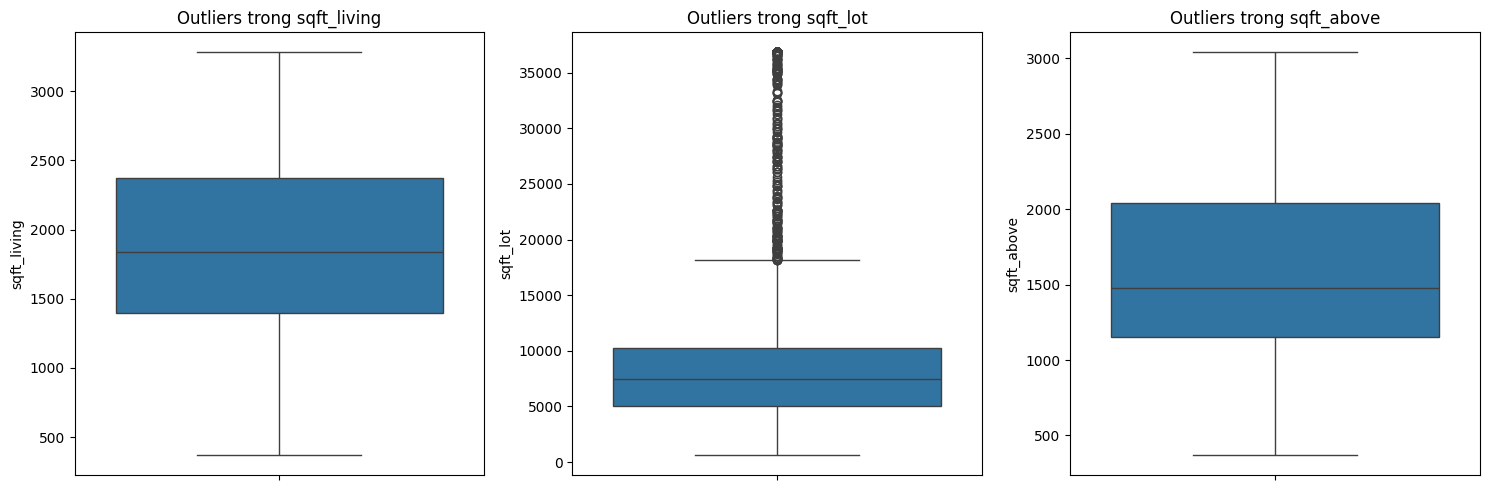

In [1127]:
cols_to_check = ['sqft_living', 'sqft_lot', 'sqft_above']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers trong {col}')
plt.tight_layout()
plt.show()

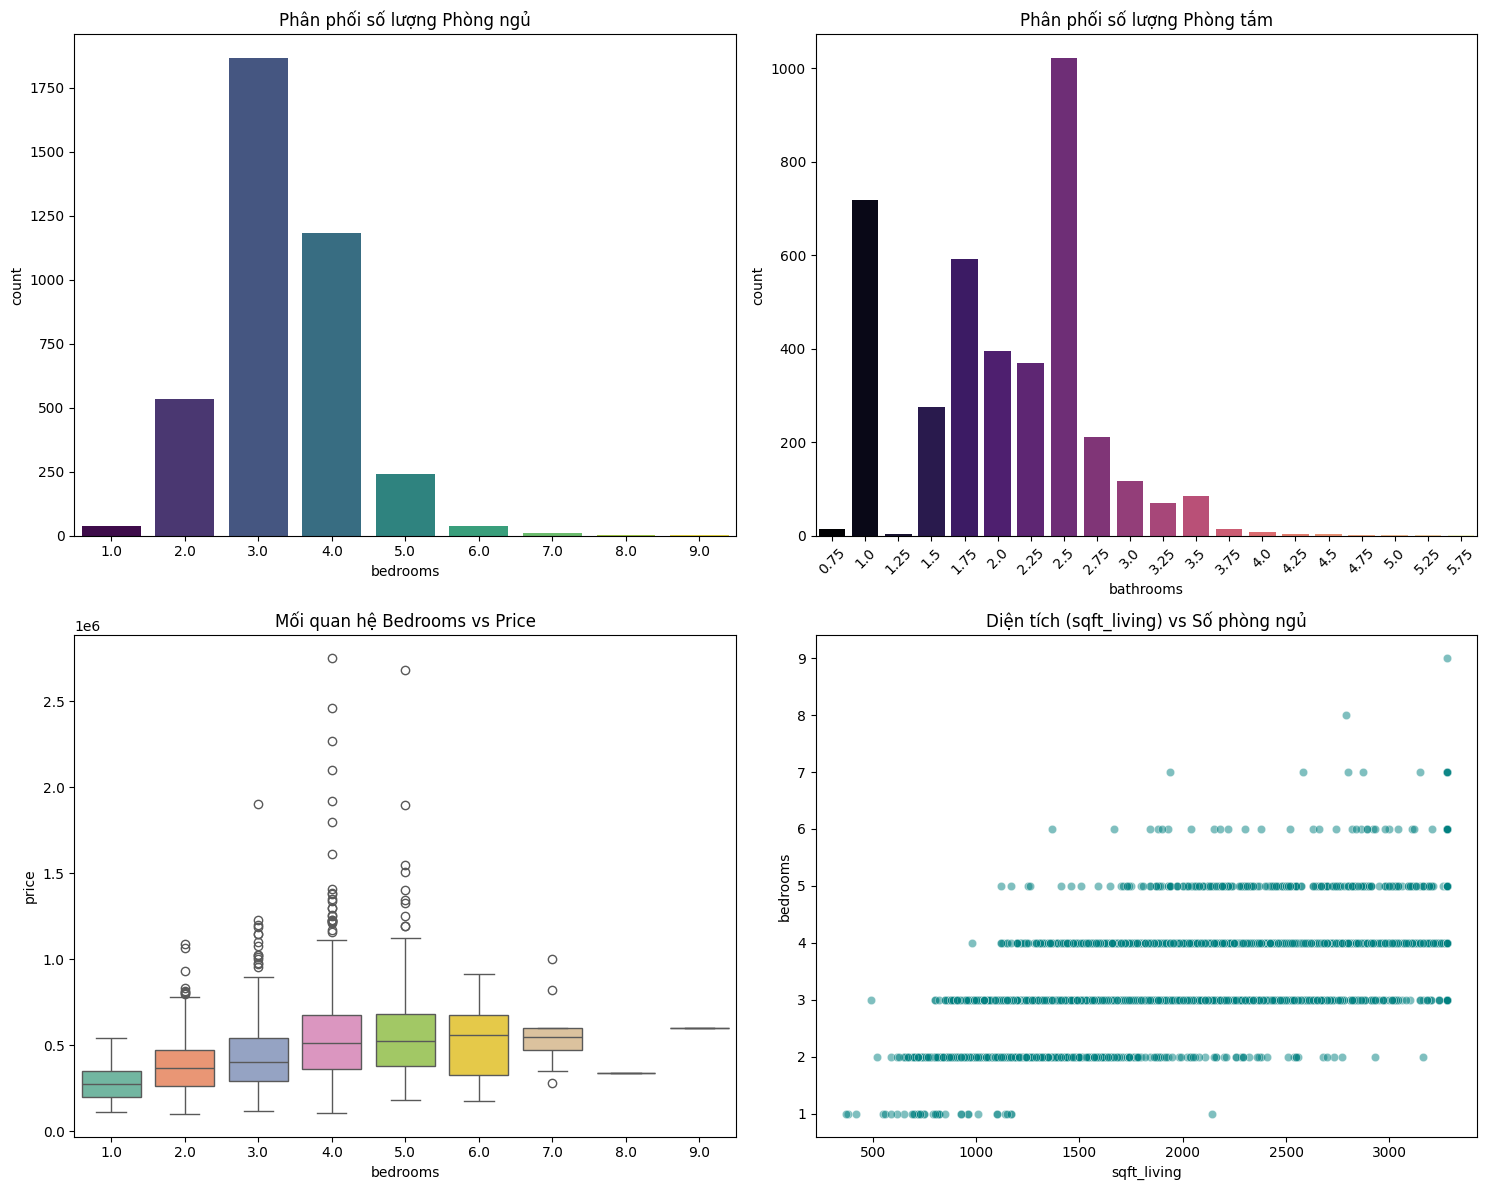

In [1128]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Phân phối số lượng Phòng ngủ (Fix warning: thêm hue và legend)
sns.countplot(x='bedrooms', data=df, ax=axes[0, 0], hue='bedrooms', palette='viridis', legend=False)
axes[0, 0].set_title('Phân phối số lượng Phòng ngủ')

# 2. Phân phối số lượng Phòng tắm
sns.countplot(x='bathrooms', data=df, ax=axes[0, 1], hue='bathrooms', palette='magma', legend=False)
axes[0, 1].set_title('Phân phối số lượng Phòng tắm')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Mối quan hệ Bedrooms vs Price (Dùng boxplot để soi các điểm dị biệt)
sns.boxplot(x='bedrooms', y='price', data=df, ax=axes[1, 0], palette='Set2', hue='bedrooms', legend=False)
axes[1, 0].set_title('Mối quan hệ Bedrooms vs Price')

# 4. Sqft_living vs Bedrooms (Scatter plot xem sự logic của diện tích và số phòng)
sns.scatterplot(x='sqft_living', y='bedrooms', data=df, ax=axes[1, 1], alpha=0.5, color='teal')
axes[1, 1].set_title('Diện tích (sqft_living) vs Số phòng ngủ')

plt.tight_layout()
plt.show()

- Dữ liệu quá ít: Bạn nhìn biểu đồ Countplot (phía trên bên trái), số lượng nhà 7, 8, 9 phòng ngủ chỉ đếm trên đầu ngón tay. Mô hình không thể học tốt từ vài mẫu đơn lẻ này.
- Giá trị sử dụng đặc thù: Những căn 8-9 phòng ngủ với diện tích chỉ khoảng 3000 $ft^2$ thường là nhà cho thuê giá rẻ hoặc nhà tập thể, nên giá bán thực tế không hề cao.

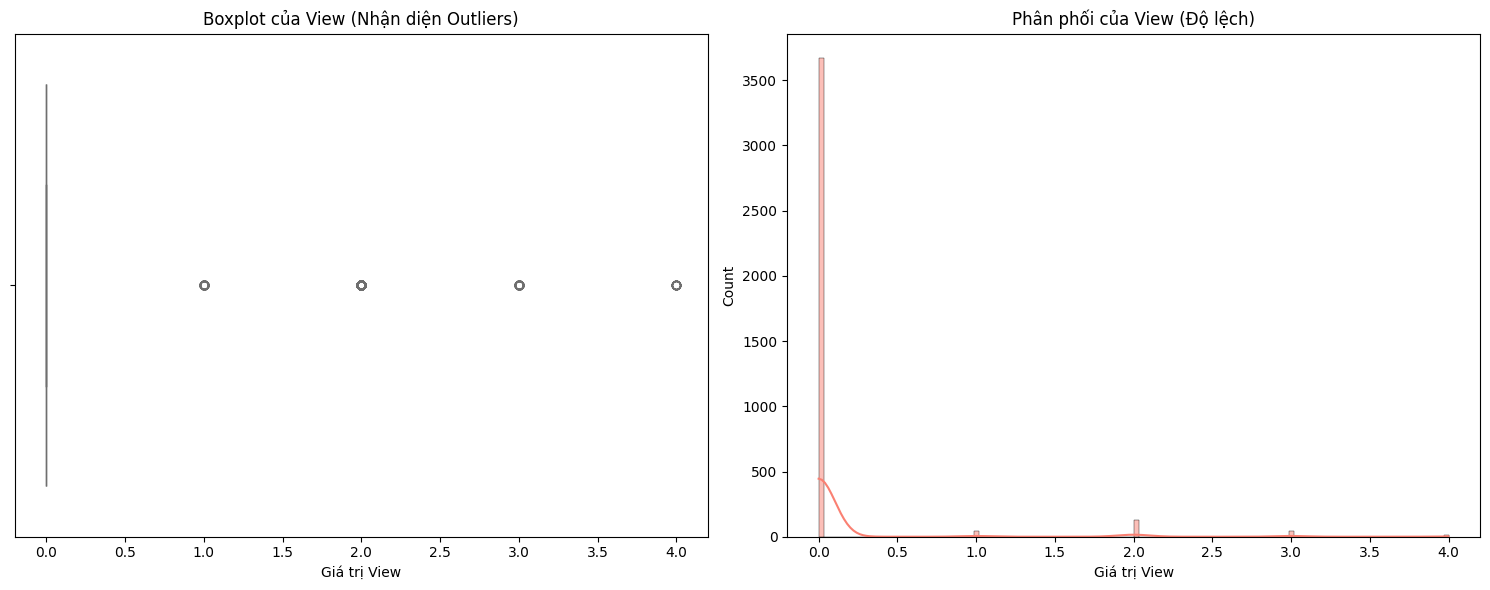

In [1129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot để thấy rõ các điểm outliers nằm ngoài khoảng quartiles
sns.boxplot(x=df['view'], ax=ax1, color='skyblue')
ax1.set_title('Boxplot của View (Nhận diện Outliers)')
ax1.set_xlabel('Giá trị View')

# 2. Histogram để xem phân phối bị lệch như thế nào
sns.histplot(df['view'], kde=True, ax=ax2, color='salmon')
ax2.set_title('Phân phối của View (Độ lệch)')
ax2.set_xlabel('Giá trị View')

plt.tight_layout()
plt.show()

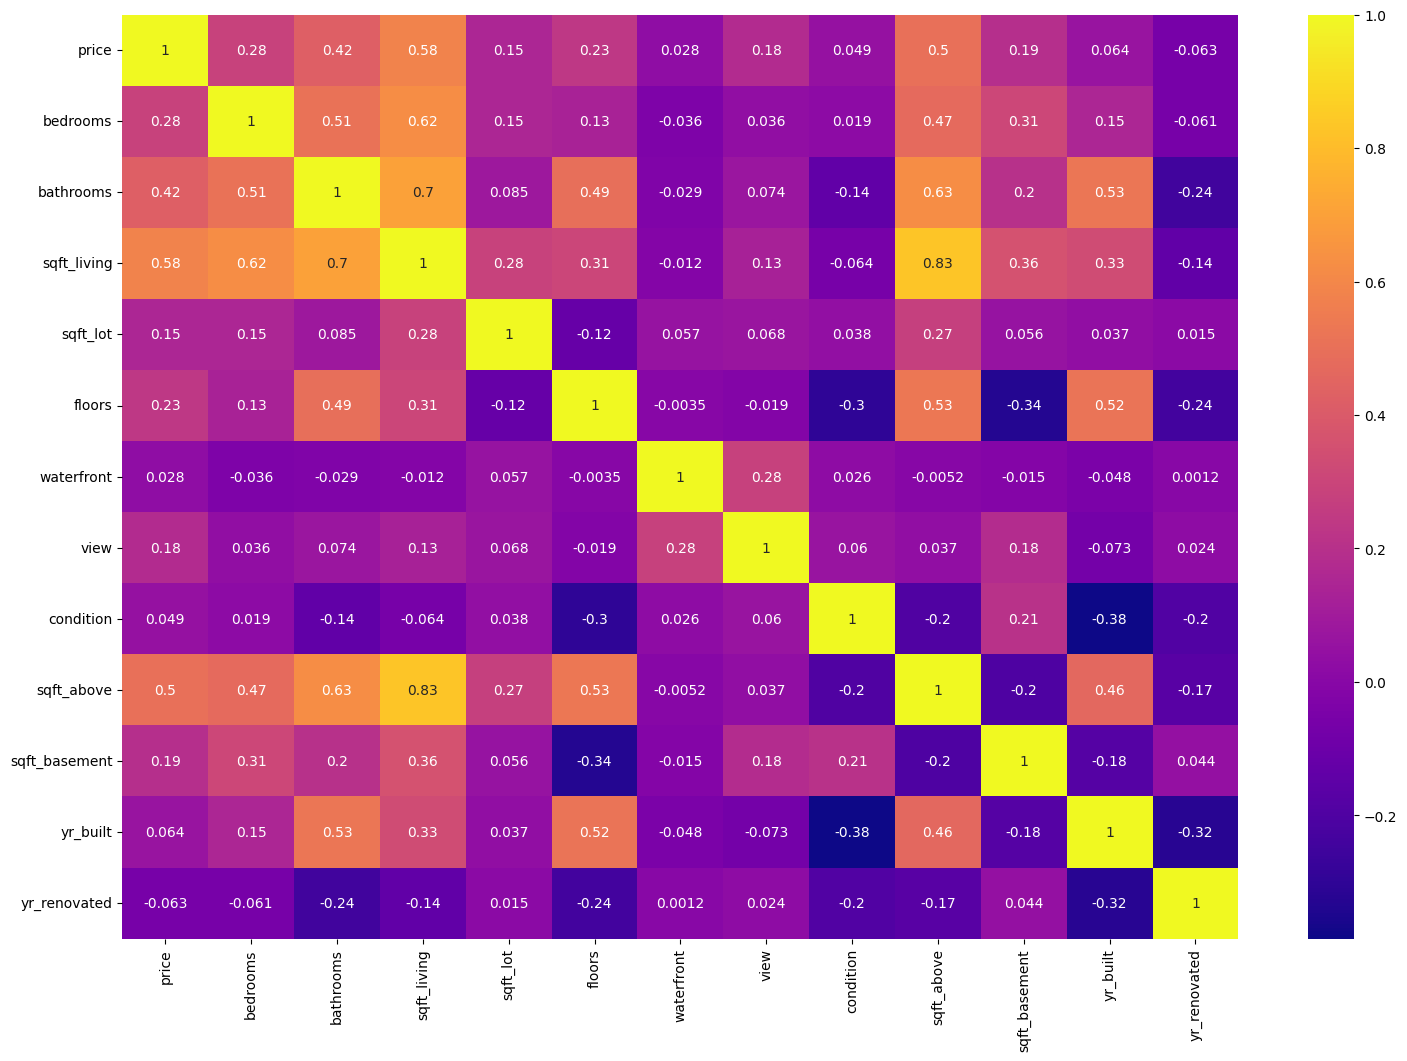

In [1130]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

### Feature Engineering

In [1131]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [1132]:
# Xử lí nốt outlier của bedroom và batroom
df['bedrooms'] = df['bedrooms'].clip(upper=7)

df['bathrooms'] = df['bathrooms'].clip(upper=4.5)

In [1133]:
df["statezip"].unique()
# 77 giá trị unique có đầu là WA -> 3 cách xử lý
    # dùng model họ nhà cây -> Label
    # dùng linear or tối ưu loss -> one-hot (tốn bộ nhớ tạo 76 cột ?)
    # Target: thay thế mã zip bằng giá nhà trung bình của khu vực đó
    # Phân nhóm theo khu vực

<ArrowStringArray>
['WA 98133', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115', 'WA 98045',
 'WA 98155', 'WA 98074', 'WA 98106', 'WA 98007', 'WA 98092', 'WA 98198',
 'WA 98006', 'WA 98102', 'WA 98125', 'WA 98003', 'WA 98136', 'WA 98033',
 'WA 98029', 'WA 98117', 'WA 98034', 'WA 98072', 'WA 98107', 'WA 98038',
 'WA 98166', 'WA 98116', 'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027',
 'WA 98059', 'WA 98075', 'WA 98014', 'WA 98011', 'WA 98199', 'WA 98065',
 'WA 98053', 'WA 98058', 'WA 98122', 'WA 98103', 'WA 98005', 'WA 98118',
 'WA 98112', 'WA 98177', 'WA 98105', 'WA 98004', 'WA 98023', 'WA 98019',
 'WA 98119', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98010', 'WA 98051', 'WA 98031',
 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178', 'WA 98040', 'WA 98288',
 'WA 98108', 'WA 98070', 'WA 98188', 'WA 98002', 'WA 98039', 'WA 98022',
 'WA 98109', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [1134]:
# Tính giá trung bình theo từng mã Zip
zip_map = df.groupby('statezip')['price'].mean()

# Thay thế cột statezip bằng giá trung bình đó
df['statezip'] = df['statezip'].map(zip_map)

In [1135]:
df['city'].unique()
# dựa vào EDA ta thấy được biến city này có outlier nên ta cần xử lý nó trước khi đưa vào model

# nên dùng median để phân chia
# có 3 cách để xử lí biến city này:
    # Cách 1: gộp theo phân khúc (Price Tiers)
    # Cách 2: giữ lại Top 10 thành phố có giá nhà đắt nhất và vùng ngoại ô giá rẻ thì chuyển hết thành 'Other'
    # Cách 3: Target Encoding như statezip

<ArrowStringArray>
[          'Shoreline',                'Kent',            'Bellevue',
             'Redmond',             'Seattle',          'North Bend',
    'Lake Forest Park',           'Sammamish',              'Auburn',
          'Des Moines',         'Federal Way',            'Kirkland',
            'Issaquah',         'Woodinville',        'Maple Valley',
       'Normandy Park',           'Fall City',              'Renton',
           'Carnation',             'Bothell',          'Snoqualmie',
              'Duvall',              'Burien',           'Covington',
 'Inglewood-Finn Hill',             'Kenmore',           'Newcastle',
       'Black Diamond',          'Ravensdale',          'Clyde Hill',
       'Mercer Island',              'Algona',           'Skykomish',
             'Tukwila',              'Vashon',        'Yarrow Point',
              'SeaTac',              'Medina',            'Enumclaw',
     'Snoqualmie Pass',             'Pacific',  'Beaux Arts Village',
 

In [1136]:
city_values = df.groupby('city')['price'].median().sort_values()
df['city_median_mapped'] = df['city'].map(city_values)

df['city_tier'] = pd.qcut(df['city_median_mapped'], q=4, labels=['Tier_4', 'Tier_3', 'Tier_2', 'Tier_1'])

In [1137]:
df.groupby('city_tier', observed=True)['price'].mean().sort_values(ascending=False).round(2)

city_tier
Tier_1    660097.64
Tier_2    533972.21
Tier_3    455342.39
Tier_4    286431.07
Name: price, dtype: float64

In [1138]:
tier_mapping = {
    'Tier_4': 1,
    'Tier_3': 2,
    'Tier_2': 3,
    'Tier_1': 4
}

df['city_tier'] = df['city_tier'].map(tier_mapping)

df['city_tier'] = df['city_tier'].astype(int)

In [1139]:
df.drop(["city", "city_median_mapped"], inplace=True, axis=1)

In [1140]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip,city_tier
0,313000.0,3.0,1.50,1340,7912.0,1.5,0,0,3,1340,0,1955,2005,368227.985019,2
2,342000.0,3.0,2.00,1930,11947.0,1.0,0,0,4,1930,0,1966,0,268342.230920,1
3,420000.0,3.0,2.25,2000,8030.0,1.0,0,0,4,1000,1000,1963,0,546181.222222,4
4,550000.0,4.0,2.50,1940,10500.0,1.0,0,0,4,1140,800,1976,1992,604472.762814,4
5,490000.0,2.0,1.00,880,6380.0,1.0,0,0,3,880,0,1938,1994,540875.233540,2


In [1141]:
from sklearn.decomposition import PCA

# Corr matrix đang bị đa cộng tuyến giữa các features với nhau nên ta cần gom lại
current_year = 2026 
df['house_age'] = current_year - df['yr_built']

df['has_basement'] = (df['sqft_basement'] > 0).astype(int)
# Features yr_renovated chuyển về binary đã từng được fix chưa
df["is_renovated"] = df['yr_renovated'].apply(lambda x: 1 if x>0 else 0)

In [1142]:
df['sqft_lot'] = np.log1p(df['sqft_lot'])
df['sqft_above'] = np.log1p(df['sqft_above'])
df['statezip'] = np.log1p(df['statezip'])
df['sqft_living'] = np.log1p(df['sqft_living'])

In [1143]:
sqft_features = ['sqft_living', 'sqft_above', 'sqft_lot']
room_features = ['bedrooms', 'bathrooms']
loc_features = ['statezip', 'city_tier']
quality_features = ['view', 'condition']

temp_scaler = MyStandardScaler()

In [1144]:
# PCA cho diện tích
sqft_scaled = temp_scaler.fit_transform(df[sqft_features])
pca_sqft = PCA(n_components=1)
df['sqft_ft'] = pca_sqft.fit_transform(sqft_scaled)

In [1145]:
# Xử lý đa cộng tuyến giữa sqft_living, bedrooms, bathrooms
df['avg_room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'])
df['avg_room_size'] = np.log1p(df['avg_room_size'])

# PCA cho cấu trúc phòng
#room_scaled = temp_scaler.fit_transform(df[room_features])
#pca_room = PCA(n_components=1)
#df['room_structure'] = pca_room.fit_transform(room_scaled)

In [1146]:
# Xử lý đa cộng tuyến cho city_tier và statezip
# C1: có thể bỏ city_tier và giữ Statezip
# C2: Sử dụng PCA
# Điều chỉnh hệ số tier 1 là tốt nhất lên khi chia sẽ không sao
# df['location_score'] = df['statezip'] / df['city_tier']

# PCA cho vị trí
loc_scaled = temp_scaler.fit_transform(df[loc_features])
pca_loc = PCA(n_components=1)
df['location_id'] = pca_loc.fit_transform(loc_scaled)

In [1147]:
# Chuyển view thành 0 (không view) và 1 (có bất kỳ view nào) vì số lượng view > 0 quá ít
#df['has_view'] = (df['view'] > 0).astype(int)

df['total_quality'] = df['view'] + df['condition']

#pca_qual = PCA(n_components=1)
#df['total_quality_index'] = pca_qual.fit_transform(temp_scaler.fit_transform(df[quality_features]))

In [1148]:
features_cols = [ 
    'location_id',        
    'avg_room_size',    
    'house_age',        
    'total_quality',
    'is_renovated',
    'waterfront',
    'has_basement',
    'sqft_ft'      
]

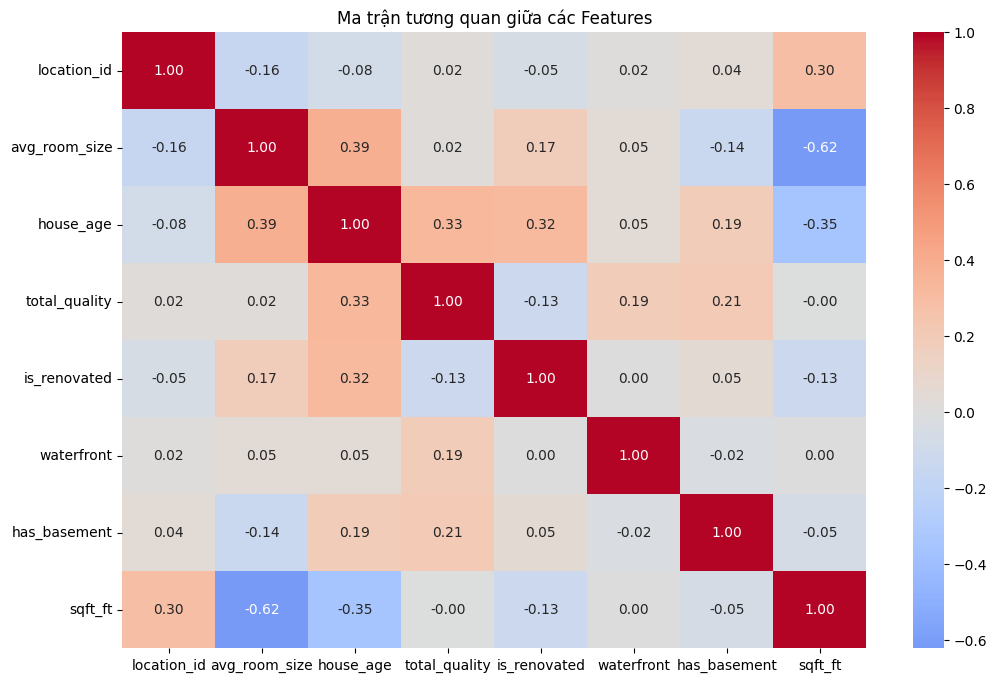

In [1149]:
plt.figure(figsize=(12, 8))
corr_matrix = df[features_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

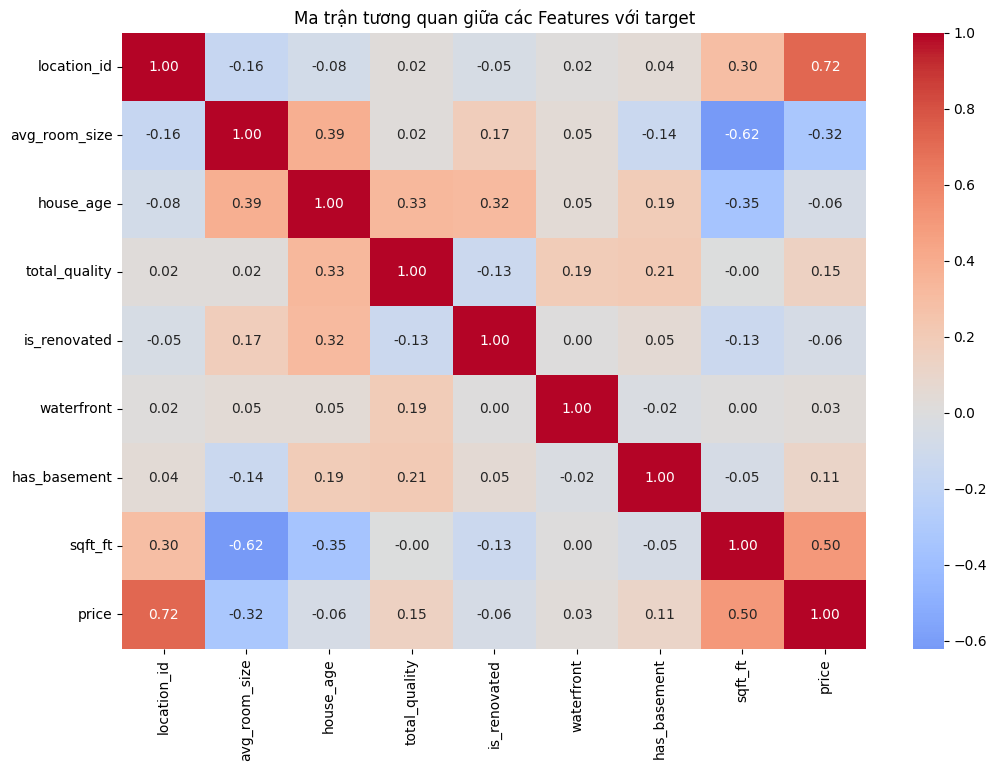

In [1150]:
check_cols = [ 
    'location_id',        
    'avg_room_size',    
    'house_age',        
    'total_quality',
    'is_renovated',
    'waterfront',
    'has_basement',
    'sqft_ft',
    'price'      
]
plt.figure(figsize=(12, 8))
corr_matrix = df[check_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các Features với target")
plt.show()

### Data processing

In [1151]:
def cap_outliers(df, column, percentile=0.98):
    upper_limit = df[column].quantile(percentile)
    df[column] = df[column].clip(upper=upper_limit)
    return df

df = cap_outliers(df, 'avg_room_size')
df = cap_outliers(df, 'total_quality')

In [1152]:
X = df[features_cols]
y = df['price']

In [1153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=172)

print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu tập Train: {len(X_train)} (~80%)")
print(f"Số mẫu tập Test:  {len(X_test)} (~20%)")


print("Kích thước ma trận Train:", X_train.shape)
print("Kích thước ma trận Test:", X_test.shape)

Tổng số mẫu: 3907
Số mẫu tập Train: 3125 (~80%)
Số mẫu tập Test:  782 (~20%)
Kích thước ma trận Train: (3125, 8)
Kích thước ma trận Test: (782, 8)


In [1154]:
from sklearn.preprocessing import RobustScaler

Cols_scale = [ 
    'location_id',
    'avg_room_size',
    'house_age',
    'total_quality',
    'sqft_ft'
]

#scaler = MyStandardScaler()

#X_train[Cols_scale] = scaler.fit_transform(X_train[Cols_scale])
#X_test[Cols_scale] = scaler.transform(X_test[Cols_scale])

robust_scaler = RobustScaler()

X_train[Cols_scale] = robust_scaler.fit_transform(X_train[Cols_scale])
X_test[Cols_scale] = robust_scaler.transform(X_test[Cols_scale])

In [1155]:
X_train_df = pd.DataFrame(X_train, columns=features_cols)
X_train_df.describe().round(2)

,location_id,avg_room_size,house_age,total_quality,is_renovated,waterfront,has_basement,sqft_ft
count,3125.00,3125.00,3125.00,3125.00,3125.00,3125.00,3125.00,3125.00
mean,0.03,0.12,0.07,0.56,0.42,0.00,0.37,0.01
std,0.57,0.79,0.67,0.82,0.49,0.05,0.48,0.71
min,-1.31,-2.03,-0.93,-2.00,0.00,0.00,0.00,-2.90
25%,-0.45,-0.49,-0.50,0.00,0.00,0.00,0.00,-0.48
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.55,0.51,0.50,1.00,1.00,0.00,1.00,0.52
max,1.76,2.00,1.66,3.00,1.00,1.00,1.00,1.55


In [1156]:
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

y_train_log = np.log1p(y_train.values)
y_test_log = np.log1p(y_test.values)

y_train_tensor = torch.FloatTensor(y_train_log).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_log).view(-1, 1)

In [1157]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 128

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Model Neural Network

In [1158]:
import numpy as np

def compute_mse(y, y_pred):
    return np.mean((y-y_pred) ** 2)

def compute_mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def compute_mape(y, y_pred):
    return 100 * np.mean(np.abs(y-y_pred) / y)

def compute_r2(y, y_pred):
    ss_res = np.mean((y - y_pred) ** 2)
    ss_tot = np.mean((y - np.mean(y)) ** 2)
        
    return 1 - (ss_res / ss_tot)

def regression_report(y, y_pred):
    mae = compute_mae(y, y_pred)
    mse = compute_mse(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = compute_r2(y, y_pred)
    mape = compute_mape(y, y_pred)

    print("Regression Report")
    print("------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")

In [1159]:
class HousePriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [1163]:
input_dim = X_train_tensor.shape[1]
model = HousePriceNN(input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

num_epochs = 800
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        
        # Forward & Backward
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * Xb.size(0)
    
    # In kết quả mỗi 50 epoch
    if (epoch + 1) % 50 == 0:
        avg_loss = epoch_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_loss:.6f}")

Epoch  50 | Train Loss: 0.158759
Epoch 100 | Train Loss: 0.108940
Epoch 150 | Train Loss: 0.094704
Epoch 200 | Train Loss: 0.092244
Epoch 250 | Train Loss: 0.069647
Epoch 300 | Train Loss: 0.069264
Epoch 350 | Train Loss: 0.064239
Epoch 400 | Train Loss: 0.053275
Epoch 450 | Train Loss: 0.053118
Epoch 500 | Train Loss: 0.055924
Epoch 550 | Train Loss: 0.051312
Epoch 600 | Train Loss: 0.049538
Epoch 650 | Train Loss: 0.046018
Epoch 700 | Train Loss: 0.045253
Epoch 750 | Train Loss: 0.040726
Epoch 800 | Train Loss: 0.045494


In [1164]:
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_tensor.to(device)).cpu().numpy()
    y_true_log = y_test_tensor.numpy()
    
# Chuyển ngược từ log1p sang giá gốc
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

regression_report(y_true, y_pred)

# (Tuỳ chọn) In thử 5 dự đoán đầu tiên
print("\nSo sánh 5 mẫu đầu tiên:")
for i in range(5):
    print(f"Thực tế: {y_true[i][0]:10,.0f} - Dự đoán: {y_pred[i][0]:10,.0f} | Sai số: {abs(y_true[i][0]-y_pred[i][0]):,.0f}")

Regression Report
------------------
MAE  : 81427.7578
MSE  : 15790417920.0000
RMSE : 125659.9297
R2   : 0.6176
MAPE : 17.6785

So sánh 5 mẫu đầu tiên:
Thực tế:    852,880 - Dự đoán:    824,311 | Sai số: 28,569
Thực tế:    565,000 - Dự đoán:    544,309 | Sai số: 20,691
Thực tế:    432,000 - Dự đoán:    569,455 | Sai số: 137,455
Thực tế:    869,000 - Dự đoán:    762,196 | Sai số: 106,804
Thực tế:    256,750 - Dự đoán:    243,808 | Sai số: 12,942


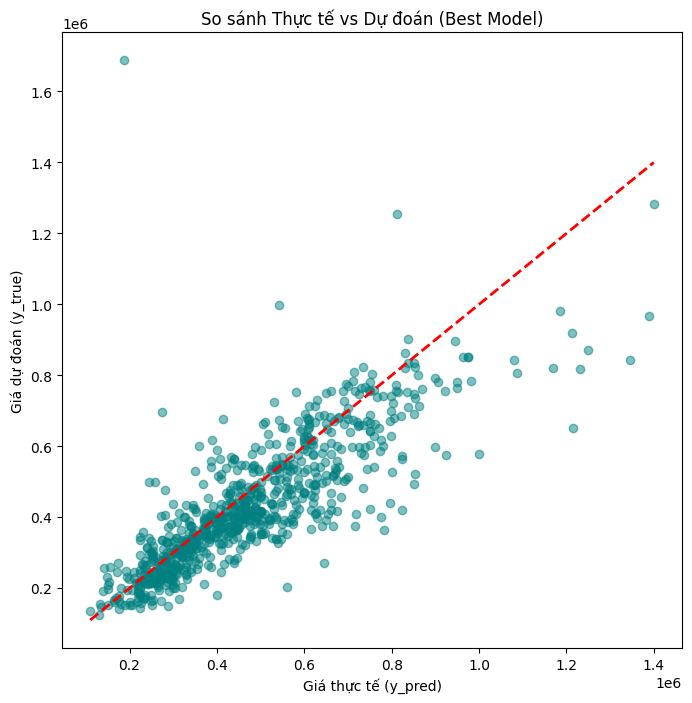

In [1165]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế (y_pred)')
plt.ylabel('Giá dự đoán (y_true)')
plt.title('So sánh Thực tế vs Dự đoán (Best Model)')
plt.show()